In [1]:
from datascience import *
%matplotlib inline
path_data = 'data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import math
import numpy as np
from scipy import stats

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
colors = Table.read_table(path_data + 'roulette_wheel.csv').column('Color')
pockets = make_array('0','00')
for i in np.arange(1, 37):
    pockets = np.append(pockets, str(i))

wheel = Table().with_columns(
    'Pocket', pockets,
    'Color', colors
)

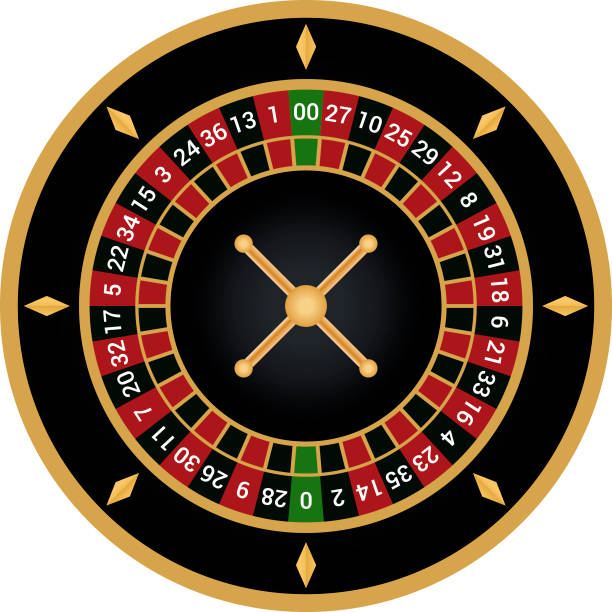

In [4]:
wheel

Pocket,Color
0,green
00,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red
8,black


# 중심 극한 정리 (Central Limit Theorem)
이 과정에서 우리가 본 데이터 히스토그램 중 종 모양(bell shaped)인 것은 거의 없었습니다. 우리가 종 모양의 분포를 마주친 경우는 거의 예외 없이 무작위 표본(random sample)에 기반한 통계량의 경험적 히스토그램이었습니다.

아래 예제들은 이러한 히스토그램에서 대략적인 종 모양이 나타나는 서로 매우 다른 두 가지 상황을 보여줍니다.

## 룰렛에서의 순수익 (Net Gain)
이전 섹션에서, 룰렛 휠을 여러 번 돌릴 때마다 동일한 베팅을 반복했을 때 얻게 될 총 금액의 대략적인 모양으로 종 모양이 나타났었습니다.

In [5]:
wheel

Pocket,Color
0,green
00,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red
8,black


빨간색에 베팅하면 1 대 1로 돈을 지급한다는 점을 상기해 봅시다. 우리는 빨간색에 \$1를 베팅했을 때의 순수익을 반환하는 `red_winnings` 함수를 정의했습니다. 구체적으로, 이 함수는 색상을 인수로 받아 색상이 빨간색이면 1을 반환합니다. 다른 모든 색상에 대해서는 -1을 반환합니다.

In [6]:
def red_winnings(color):
    if color == 'red':
        return 1
    else:
        return -1

`red` 테이블은 각 주머니(pocket)에 대한 빨간색 베팅의 수익을 보여줍니다.

In [7]:
red = wheel.with_column(
    'Winnings: Red', wheel.apply(red_winnings, 'Color')
    )
red

Pocket,Color,Winnings: Red
0,green,-1
00,green,-1
1,red,1
2,black,-1
3,red,1
4,black,-1
5,red,1
6,black,-1
7,red,1
8,black,-1


In [8]:
red.column('Winnings: Red').sum()

-2

한 번의 베팅에서 얻는 순수익은 `Winnings: Red` 열에서 무작위로 하나를 추출한 것입니다. \$1를 벌 확률은 18/38이고, -\$1를 벌 확률은 20/38입니다. 이 확률 분포는 아래 히스토그램에 나타나 있습니다.

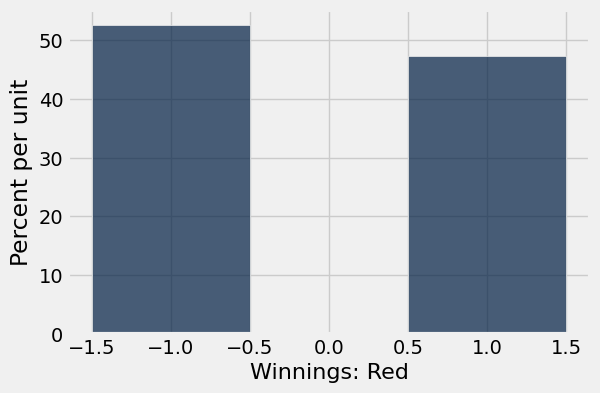

In [9]:
red.select('Winnings: Red').hist(bins=np.arange(-1.5, 1.6, 1))

이제 빨간색에 여러 번 베팅한다고 가정해 봅시다. 여러분의 순수익은 위 분포에서 복원 추출(random with replacement)로 여러 번 추출한 값들의 합이 될 것입니다.

가능한 모든 순수익 값과 각각의 확률을 나열하려면 약간의 수학이 필요합니다. 우리는 그렇게 하지 않고, 이 과정 내내 해왔던 것처럼 시뮬레이션을 통해 확률 분포를 근사해 보겠습니다.

아래 코드는 룰렛 휠을 400번 돌릴 때 빨간색에 \$1씩 베팅했을 때의 순수익을 시뮬레이션합니다.

In [10]:
num_bets = 400
repetitions = 10000

net_gain_red = make_array()

for i in np.arange(repetitions):
    spins = red.sample(num_bets)
    new_net_gain_red = spins.column('Winnings: Red').sum()
    net_gain_red = np.append(net_gain_red, new_net_gain_red)


results = Table().with_column(
    'Net Gain on Red', net_gain_red
    )

In [11]:
results

Net Gain on Red
-28
-24
-4
-10
2
14
-26
-38
-16
0


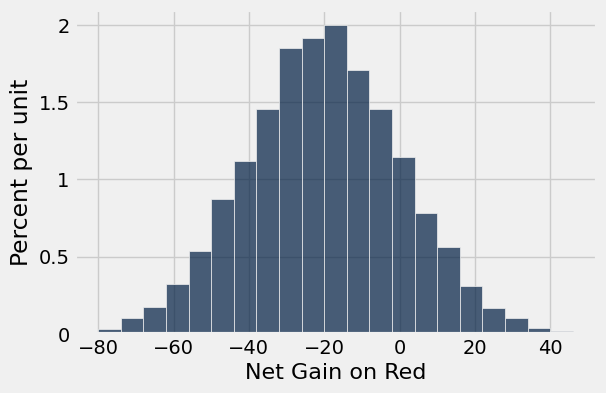

In [12]:
results.hist(bins=np.arange(-80, 50, 6))

우리가 추출하는 모집단의 분포가 전혀 종 모양이 아님에도 불구하고, 이는 대략 종 모양의 히스토그램입니다.

**중심 (Center).** 분포는 대략 -20달러 근처에 중심이 있습니다. 그 이유를 알아보면, 베팅의 약 18/38에서 \$1를 따고, 나머지 20/38에서 -\$1를 잃게 됩니다. 따라서 1달러 베팅당 평균 수익은 대략 -5.26센트가 됩니다:

In [13]:
average_per_bet = 1*(18/38) + (-1)*(20/38)
average_per_bet

-0.05263157894736842

따라서 400번의 베팅에서 순수익은 약 -\$21가 될 것으로 예상할 수 있습니다:

In [14]:
400 * average_per_bet

-21.052631578947366

확인을 위해, 10,000번의 시뮬레이션된 순수익의 평균을 계산해 볼 수 있습니다.

In [15]:
np.mean(results.column(0))

-21.108599999999999

**퍼짐 (Spread).** 중심에서 시작하여 곡선을 따라 눈을 움직여 보면 변곡점(point of inflection)이 0 근처에 있음을 알 수 있습니다. 종 모양의 곡선에서 표준편차(SD)는 중심에서 변곡점까지의 거리입니다. 중심이 대략 -\$20이므로, 분포의 SD는 약 \$20입니다.

다음 섹션에서 이 \$20가 어디서 나왔는지 살펴볼 것입니다. 지금은 10,000번의 시뮬레이션된 순수익의 SD를 계산하여 관찰 내용을 확인해 보겠습니다.

In [16]:
np.std(results.column(0))

20.345677822082997

**요약.** 400번의 베팅에서 얻은 순수익은 각 개별 베팅에서 얻은 400개 금액의 합입니다. 그 합의 확률 분포는 대략적으로 정규분포(normal distribution)를 따르며, 평균과 SD를 근사할 수 있습니다.

## 평균 항공편 지연 (Average Flight Delay)
`united` 테이블에는 2015년 여름 샌프란시스코 공항에서 출발한 13,825편의 유나이티드 항공 국내선 항공편의 출발 지연 데이터가 포함되어 있습니다. 이전에 보았듯이 지연 분포는 오른쪽 꼬리가 긴 형태를 띱니다.

In [17]:
united = Table.read_table(path_data + 'united_summer2015.csv')

In [18]:
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


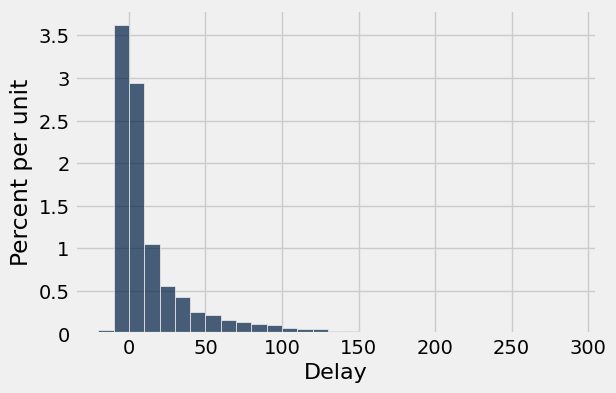

In [19]:
united.select('Delay').hist(bins=np.arange(-20, 300, 10))

평균 지연 시간은 약 16.6분이고 SD는 약 39.5분이었습니다. 평균에 비해 SD가 얼마나 큰지 주목하십시오. 오른쪽의 큰 편차들은 데이터의 아주 작은 비율임에도 불구하고 영향을 미칩니다.

In [20]:
mean_delay = np.mean(united.column('Delay'))
sd_delay = np.std(united.column('Delay'))

mean_delay, sd_delay

(16.658155515370705, 39.480199851609314)

이제 400개의 지연을 복원 추출로 무작위 표본 추출한다고 가정해 봅시다. 비복원 추출을 할 수도 있지만, 결과는 복원 추출과 매우 유사할 것입니다. 13,825개 중 수백 개를 비복원 추출하더라도, 값을 하나 꺼낼 때마다 모집단은 거의 변하지 않기 때문입니다.

표본에서 평균 지연 시간은 얼마가 될까요? 모집단 평균이 16 또는 17 정도이므로 그 근처가 될 것으로 예상하지만, 다소 차이가 있을 수 있습니다. 표본 추출을 통해 어떤 결과를 얻는지 확인해 봅시다. 지연 열만 포함된 `delay` 테이블을 사용하여 작업하겠습니다.

In [21]:
delay = united.select('Delay')

In [45]:
np.mean(delay.sample(400).column('Delay'))

19.012499999999999

표본 평균은 표본이 어떻게 나오느냐에 따라 달라지므로, 표본 추출 과정을 반복적으로 시뮬레이션하고 표본 평균의 경험적 히스토그램을 그려보겠습니다. 이는 표본 평균의 확률 히스토그램에 대한 근사치가 될 것입니다.

In [46]:
sample_size = 400
repetitions = 10000

means = make_array()

for i in np.arange(repetitions):
    sample = delay.sample(sample_size)
    new_mean = np.mean(sample.column('Delay'))
    means = np.append(means, new_mean)

results = Table().with_column(
    'Sample Mean', means
)

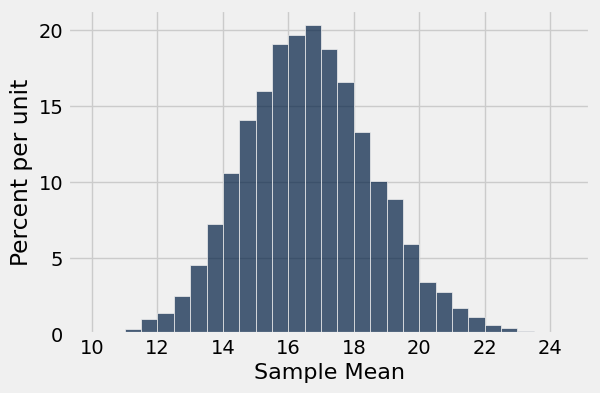

In [47]:
results.hist(bins=np.arange(10, 25, 0.5))

In [48]:
np.mean(results.column(0))

16.655510249999999

다시 한번, 매우 편향된(skewed) 분포에서 추출했음에도 불구하고 대략적인 종 모양을 볼 수 있습니다. 예상대로 종 모양의 중심은 16과 17 사이에 위치합니다.

## 중심 극한 정리 (Central Limit Theorem)

이러한 상황에서 종 모양이 나타나는 이유는 **중심 극한 정리(Central Limit Theorem)**라고 불리는 확률 이론의 놀라운 결과 때문입니다.

**중심 극한 정리는 복원 추출로 얻은 큰 무작위 표본의 합이나 평균의 확률 분포가 *표본이 추출된 모집단의 분포와 상관없이* 대략적으로 정규분포를 따른다는 것을 말해줍니다.**

체비쇼프(Chebychev) 부등식을 공부할 때 언급했듯이, *모집단의 분포와 상관없이* 무작위 표본에 적용할 수 있는 결과는 매우 강력합니다. 왜냐하면 데이터 과학에서는 모집단의 분포를 아는 경우가 거의 없기 때문입니다.

중심 극한 정리는 큰 무작위 표본이 있다면 모집단에 대한 지식이 거의 없어도 추론을 가능하게 합니다. 이것이 바로 통계적 추론 분야에서 이 정리가 중심이 되는 이유입니다.

## 보라색 꽃의 비율 (Proportion of Purple Flowers)
완두콩 식물 종의 꽃 색깔에 대한 멘델의 확률 모델을 상기해 봅시다. 이 모델은 식물의 꽃 색깔이 {보라색, 보라색, 보라색, 흰색}에서 복원 추출로 무작위로 뽑은 것과 같다고 말합니다.

식물의 큰 표본에서 보라색 꽃의 비율은 대략 얼마나 될까요? 우리는 그 답이 모델에서의 보라색 비율인 약 0.75가 될 것이라고 예상합니다. 그리고 비율(proportion)은 평균(mean)의 일종이므로, 중심 극한 정리에 따라 보라색 식물의 표본 비율 분포는 대략적으로 정규분포를 따릅니다.

우리는 시뮬레이션을 통해 이것을 확인할 수 있습니다. 200개의 식물 표본에서 보라색 꽃이 피는 식물의 비율을 시뮬레이션해 봅시다.

In [ ]:
colors = make_array('Purple', 'Purple', 'Purple', 'White')

model = Table().with_column('Color', colors)

model

Color
Purple
Purple
Purple
White


In [ ]:
props = make_array()

num_plants = 200
repetitions = 10000

for i in np.arange(repetitions):
    sample = model.sample(num_plants)
    new_prop = np.count_nonzero(sample.column('Color') == 'Purple')/num_plants
    props = np.append(props, new_prop)

results = Table().with_column('Sample Proportion: 200', props)

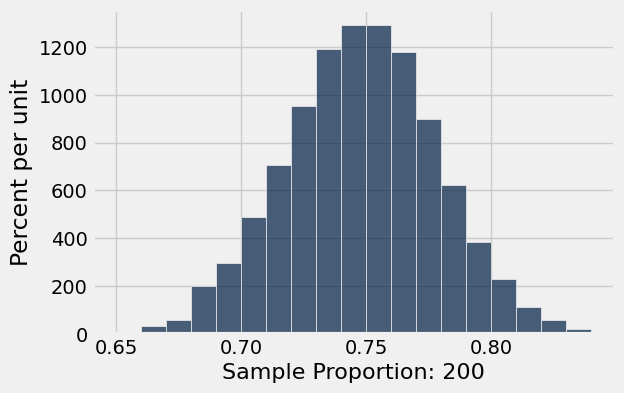

In [ ]:
results.hist(bins=np.arange(0.65, 0.85, 0.01))

In [ ]:
np.mean(results.column(0))

0.74998050000000005

중심 극한 정리가 예측한 대로, 다시 한번 정규 곡선이 나타났으며 예상대로 0.75 근처에 중심이 있습니다.

표본 크기를 늘리면 이 분포는 어떻게 변할까요? 표본 크기를 800으로 하여 코드를 다시 실행하고, 200개 표본 크기에 기반한 시뮬레이션 결과를 수집했던 동일한 테이블에 결과를 모아보겠습니다. 두 열의 길이가 같도록 `repetitions` 횟수는 이전과 동일하게 유지하겠습니다.

In [ ]:
props2 = make_array()

num_plants = 800

for i in np.arange(repetitions):
    sample = model.sample(num_plants)
    new_prop = np.count_nonzero(sample.column('Color') == 'Purple')/num_plants
    props2 = np.append(props2, new_prop)

results = results.with_column('Sample Proportion: 800', props2)

In [ ]:
results

Sample Proportion: 200,Sample Proportion: 800
0.745,0.73875
0.715,0.755
0.765,0.75
0.735,0.765
0.76,0.72875
0.77,0.76125
0.735,0.7675
0.795,0.74125
0.77,0.7425
0.785,0.7625


In [ ]:
np.mean(results.column(1))

0.7498315000000001

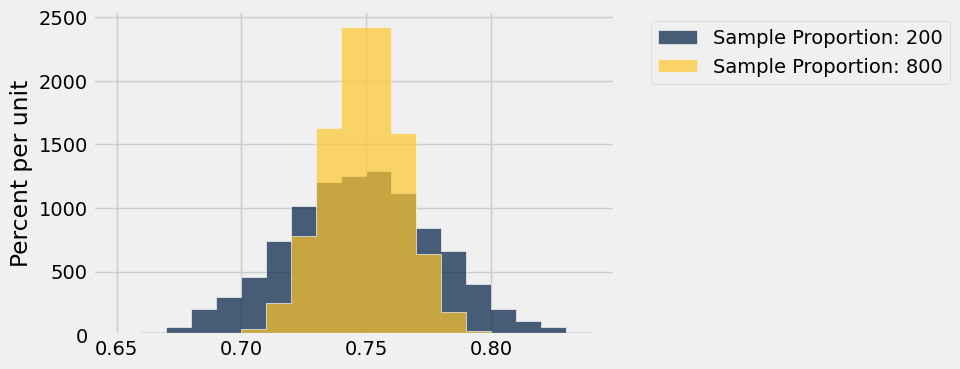

In [ ]:
results.hist(bins=np.arange(0.65, 0.85, 0.01))

두 분포 모두 대략적으로 정규분포이지만 하나가 다른 것보다 좁습니다. 표본 크기가 800일 때의 비율은 표본 크기가 200일 때보다 0.75 주위에 더 밀집해 있습니다. 표본 크기를 늘리면 표본 비율의 변동성(variability)이 감소했습니다.

이는 놀라운 일이 아닙니다. 우리는 표본 크기가 클수록 통계량의 변동성이 줄어든다는 직관에 여러 번 의존해 왔습니다. 하지만 표본 평균의 경우, 표본 크기와 변동성 사이의 관계를 *정량화(quantify)*할 수 있습니다.

표본 크기가 표본 평균이나 비율의 변동성에 정확히 어떤 영향을 미칠까요? 이것이 우리가 다음 섹션에서 살펴볼 질문입니다.